In [ ]:
import os
import cv2
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, cohen_kappa_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# ==========================================
# 1. CONFIGURATION (UPDATED PATHS)
# ==========================================
# Base folder where CSVs are located
BASE_DIR = r"C:\Users\gouth\Downloads\RSNA_dataset"

# Exact paths to the image subfolders
TRAIN_IMG_DIR = r"C:\Users\gouth\Downloads\RSNA_dataset\boneage-training-dataset"
TEST_IMG_DIR = r"C:\Users\gouth\Downloads\RSNA_dataset\boneage-test-dataset"

# CSV Files
TRAIN_CSV = os.path.join(BASE_DIR, "boneage-training-dataset.csv")
TEST_CSV = os.path.join(BASE_DIR, "boneage-test-dataset.csv")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 384
BATCH_SIZE = 16 
LEARNING_RATE = 1e-4
EPOCHS = 15
MAX_AGE_SCALE = 240.0 # Normalize ages (0-240 months) to (0-1)

print(f"✅ Device: {DEVICE}")
print(f"✅ Train Images: {TRAIN_IMG_DIR}")
print(f"✅ Test Images: {TEST_IMG_DIR}")

✅ Device: cuda
✅ Train Images: C:\Users\gouth\Downloads\RSNA_dataset\boneage-training-dataset
✅ Test Images: C:\Users\gouth\Downloads\RSNA_dataset\boneage-test-dataset


In [ ]:
def process_dataframe(csv_path, img_folder, is_training=True):
    df = pd.read_csv(csv_path)
    
    # 1. Standardize 'id'
    if 'Case ID' in df.columns:
        df.rename(columns={'Case ID': 'id'}, inplace=True)
    
    # 2. Standardize 'sex' (M/F -> 1/0)
    if 'male' in df.columns:
        df['sex'] = df['male'].apply(lambda x: 1 if x else 0)
    elif 'Sex' in df.columns:
        df['sex'] = df['Sex'].apply(lambda x: 1 if x == 'M' else 0)
    
    # 3. Rename target
    if 'boneage' in df.columns:
        df.rename(columns={'boneage': 'bone_age'}, inplace=True)

    # 4. Create Image Paths (Using the passed img_folder)
    # We assume .png first based on your folder structure
    df['path'] = df['id'].apply(lambda x: os.path.join(img_folder, f"{x}.png"))
    
    # 5. Create Stages (Child/Adolescent/Adult) for Classification Task
    if is_training and 'bone_age' in df.columns:
        def get_stage(months):
            if months < 144: return 0  # Child (<12y)
            elif months < 216: return 1 # Adolescent (12-18y)
            else: return 2              # Adult (>18y)
        df['stage'] = df['bone_age'].apply(get_stage)
        
    return df

# Load Data
print("Processing Dataframes...")
full_train_df = process_dataframe(TRAIN_CSV, TRAIN_IMG_DIR, is_training=True)
external_test_df = process_dataframe(TEST_CSV, TEST_IMG_DIR, is_training=False)

# Split: 70% Train, 15% Val, 15% Internal Test
train_df, temp_df = train_test_split(full_train_df, test_size=0.3, stratify=full_train_df['sex'], random_state=42)
val_df, internal_test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['sex'], random_state=42)

print(f"Train Size: {len(train_df)} | Val Size: {len(val_df)} | Internal Test Size: {len(internal_test_df)}")

Processing Dataframes...
Train Size: 8827 | Val Size: 1892 | Internal Test Size: 1892


In [3]:
class BoneAgeDataset(Dataset):
    def __init__(self, df, transform=None, labeled=True):
        self.df = df
        self.transform = transform
        self.labeled = labeled

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['path']
        
        # Robust Loading
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            # Fallback: maybe it is a jpg?
            img_path = img_path.replace(".png", ".jpg")
            try:
                image = Image.open(img_path).convert('RGB')
            except:
                # Last resort: Black image (Prevent crash)
                image = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
            
        if self.transform:
            image = self.transform(image)
            
        sex = torch.tensor(row['sex'], dtype=torch.float32)
        
        if self.labeled:
            age = torch.tensor(row['bone_age'], dtype=torch.float32)
            stage = torch.tensor(row['stage'], dtype=torch.long)
            return image, sex, age, stage
        else:
            return image, sex, row['id']

# Transforms
train_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20), # Augmentation
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Loaders
train_loader = DataLoader(BoneAgeDataset(train_df, train_tfm), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(BoneAgeDataset(val_df, val_tfm), batch_size=BATCH_SIZE)
test_loader = DataLoader(BoneAgeDataset(internal_test_df, val_tfm), batch_size=BATCH_SIZE)

In [4]:
class ResNetBoneModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Backbone: ResNet50
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity() # Remove head
        
        # 1. Regression Head (Age)
        self.age_head = nn.Sequential(
            nn.Linear(num_features + 1, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 1)
        )
        
        # 2. Classification Head (Stage)
        self.stage_head = nn.Sequential(
            nn.Linear(num_features + 1, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 3)
        )

    def forward(self, img, sex):
        # Extract Features
        features = self.backbone(img)
        # Combine with Sex
        combined = torch.cat([features, sex.unsqueeze(1)], dim=1)
        
        return self.age_head(combined), self.stage_head(combined)

model = ResNetBoneModel().to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)
criterion_reg = nn.L1Loss()
criterion_cls = nn.CrossEntropyLoss()

c:\Users\gouth\OneDrive\Desktop\prmlpro\bone_env\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [5]:
import copy

# ==========================================
# 5. ROBUST LONG TRAINING (75 Epochs)
# ==========================================
# 75 Epochs = ~12.5 Hours (The "Perfect" Run)
EPOCHS = 75 

print(f"🚀 Starting Long Training for {EPOCHS} Epochs...")
print("   (Model will be saved automatically to 'best_bone_age_model.pth')")

best_model_wts = copy.deepcopy(model.state_dict())
best_loss = float('inf')
save_path = "best_bone_age_model.pth"

for epoch in range(EPOCHS):
    start_time = time.time()
    model.train()
    total_loss = 0
    
    # --- TRAIN STEP ---
    for imgs, sexes, ages, stages in train_loader:
        imgs, sexes = imgs.to(DEVICE), sexes.to(DEVICE)
        ages, stages = ages.to(DEVICE), stages.to(DEVICE)
        
        # Normalize target to [0, 1] range
        norm_ages = ages / MAX_AGE_SCALE
        
        optimizer.zero_grad()
        p_age, p_stage = model(imgs, sexes)
        
        loss_reg = criterion_reg(p_age.squeeze(), norm_ages)
        loss_cls = criterion_cls(p_stage, stages)
        
        # Weighting: 10x for regression
        loss = (loss_reg * 10.0) + loss_cls 
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    # --- VALIDATION STEP ---
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, sexes, ages, stages in val_loader:
            imgs, sexes = imgs.to(DEVICE), sexes.to(DEVICE)
            norm_ages = ages.to(DEVICE) / MAX_AGE_SCALE
            p_age, p_stage = model(imgs, sexes)
            
            val_loss += (criterion_reg(p_age.squeeze(), norm_ages) * 10.0) + criterion_cls(p_stage, stages.to(DEVICE))
            
    avg_train_loss = total_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    
    # --- DYNAMIC LEARNING RATE ---
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(avg_val_loss)
    new_lr = optimizer.param_groups[0]['lr']
    
    if new_lr < old_lr:
        print(f"   📉 LR Decreased: {old_lr:.6f} -> {new_lr:.6f}")
    
    duration = time.time() - start_time
    print(f"Epoch {epoch+1}/{EPOCHS} | {duration:.0f}s | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    # --- SAVE BEST MODEL ---
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), save_path)
        print(f"   💾 New Best Model Saved! (Val Loss: {best_loss:.4f})")

print("✅ Training Complete.")
print(f"Training finished! Best model is saved at: {os.path.abspath(save_path)}")

# Load the best weights for the next steps
model.load_state_dict(torch.load(save_path))

🚀 Starting Long Training for 75 Epochs...
   (Model will be saved automatically to 'best_bone_age_model.pth')
Epoch 1/75 | 473s | Train Loss: 2.9534 | Val Loss: 1.2779
   💾 New Best Model Saved! (Val Loss: 1.2779)
Epoch 2/75 | 423s | Train Loss: 2.0114 | Val Loss: 1.6798
Epoch 3/75 | 421s | Train Loss: 1.7337 | Val Loss: 2.2315
   📉 LR Decreased: 0.000100 -> 0.000050
Epoch 4/75 | 420s | Train Loss: 1.5886 | Val Loss: 5.7063
Epoch 5/75 | 419s | Train Loss: 1.4111 | Val Loss: 5.7799
Epoch 6/75 | 420s | Train Loss: 1.3075 | Val Loss: 1.2808
Epoch 7/75 | 420s | Train Loss: 1.2673 | Val Loss: 1.2051
   💾 New Best Model Saved! (Val Loss: 1.2051)
Epoch 8/75 | 420s | Train Loss: 1.2122 | Val Loss: 10.3396
Epoch 9/75 | 421s | Train Loss: 1.1520 | Val Loss: 47.5930
Epoch 10/75 | 422s | Train Loss: 1.1846 | Val Loss: 1.1160
   💾 New Best Model Saved! (Val Loss: 1.1160)
Epoch 11/75 | 421s | Train Loss: 1.1385 | Val Loss: 0.9150
   💾 New Best Model Saved! (Val Loss: 0.9150)
Epoch 12/75 | 419s | Tra

<All keys matched successfully>

In [6]:
# ==========================================
# 🛠️ LOAD SAVED MODEL (Run this INSTEAD of Training)
# ==========================================
save_path = "best_bone_age_model.pth"

if os.path.exists(save_path):
    print(f"Found saved model: {save_path}")
    # 1. Re-initialize the architecture
    model = ResNetBoneModel().to(DEVICE)
    
    # 2. Load the weights
    model.load_state_dict(torch.load(save_path))
    model.eval()
    print("✅ Model loaded successfully! You can skip directly to Feature Extraction.")
else:
    print("❌ No saved model found! You need to train first.")

Found saved model: best_bone_age_model.pth
✅ Model loaded successfully! You can skip directly to Feature Extraction.


In [7]:
# ==========================================
# 6. FEATURE EXTRACTION (TRAIN / VAL / TEST)
# ==========================================
def extract_features(loader, model, device):
    model.eval()
    feats_list, age_list, sex_list = [], [], []
    
    print("Extracting features...")
    with torch.no_grad():
        for imgs, sexes, ages, _ in loader:
            imgs = imgs.to(device)
            # Extract features from backbone
            f = model.backbone(imgs)
            f = f.view(f.size(0), -1) 
            
            feats_list.append(f.cpu().numpy())
            age_list.append(ages.numpy())
            sex_list.append(sexes.numpy())
            
    X = np.vstack(feats_list)
    y = np.concatenate(age_list)
    s = np.concatenate(sex_list)
    
    # Add Sex as feature (* 5.0 for importance)
    X_final = np.hstack([X, s.reshape(-1, 1) * 5.0]) 
    return X_final, y

print("1. Extracting TRAIN Features...")
X_train, y_train = extract_features(train_loader, model, DEVICE)

print("2. Extracting VAL Features (For Weight Tuning)...")
X_val, y_val = extract_features(val_loader, model, DEVICE)

print("3. Extracting TEST Features (For Final Report)...")
X_test, y_test = extract_features(test_loader, model, DEVICE)

1. Extracting TRAIN Features...
Extracting features...
2. Extracting VAL Features (For Weight Tuning)...
Extracting features...
3. Extracting TEST Features (For Final Report)...
Extracting features...


In [8]:
# ==========================================
# 7. TRAIN ENSEMBLE & PREPARE VALIDATION
# ==========================================
# 1. Train XGBoost on TRAIN data
print("Training XGBoost...")
xgb_model = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.01, max_depth=5, n_jobs=-1, random_state=42)
xgb_model.fit(X_train, y_train)

# 2. Train Ridge on TRAIN data
print("Training Ridge...")
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
ridge = Ridge(alpha=10)
ridge.fit(X_train_s, y_train)

# 3. GENERATE PREDICTIONS FOR VALIDATION SET (To tune weights)
print("Generating Validation Predictions...")
xgb_val_pred = xgb_model.predict(X_val)
ridge_val_pred = ridge.predict(scaler.transform(X_val))

dl_val_pred = []
model.eval()
with torch.no_grad():
    for imgs, sexes, _, _ in val_loader:
        imgs, sexes = imgs.to(DEVICE), sexes.to(DEVICE)
        p_age, _ = model(imgs, sexes)
        dl_val_pred.extend((p_age * MAX_AGE_SCALE).cpu().squeeze().numpy())
dl_val_pred = np.array(dl_val_pred)

print("✅ Predictions Ready for Optimizer.")

Training XGBoost...
Training Ridge...
Generating Validation Predictions...
✅ Predictions Ready for Optimizer.


In [9]:
from scipy.optimize import minimize

# ==========================================
# 8. OPTIMIZE WEIGHTS (USING VALIDATION SET)
# ==========================================
print("🧪 Optimizing Weights on Validation Set...")

# Stack Validation Predictions
val_matrix = np.column_stack((dl_val_pred, xgb_val_pred, ridge_val_pred))

# Loss Function (Minimize MAE on Validation)
def mae_loss(weights):
    final_p = np.dot(val_matrix, weights)
    return mean_absolute_error(y_val, final_p)

# Constraints
cons = ({'type': 'eq', 'fun': lambda w: 1 - sum(w)})
bnds = ((0, 1), (0, 1), (0, 1))

# Run Optimizer
result = minimize(mae_loss, [0.33, 0.33, 0.33], method='SLSQP', bounds=bnds, constraints=cons)
opt_weights = result.x

print("\n✅ FOUND OPTIMAL WEIGHTS (From Val Set):")
print(f"  Deep Learning: {opt_weights[0]:.4f}")
print(f"  XGBoost:       {opt_weights[1]:.4f}")
print(f"  Ridge:         {opt_weights[2]:.4f}")
print(f"  (Val MAE: {result.fun:.4f})")

🧪 Optimizing Weights on Validation Set...

✅ FOUND OPTIMAL WEIGHTS (From Val Set):
  Deep Learning: 0.0360
  XGBoost:       0.8733
  Ridge:         0.0907
  (Val MAE: 7.4317)


In [12]:
# ==========================================
# 8b. GENERATE TEST PREDICTIONS (FIXED)
# ==========================================
print("Generating predictions for the Test Set...")

# 1. Get XGBoost & Ridge Predictions (using X_test from earlier)
# (Ensure X_test is on CPU/Numpy format, which it should be from Cell 6)
xgb_test_pred = xgb_model.predict(X_test)
ridge_test_pred = ridge.predict(scaler.transform(X_test))

# 2. Get Deep Learning Predictions
dl_test_pred = []
model.eval()
with torch.no_grad():
    for imgs, sexes, _, _ in test_loader:
        # --- FIX: MOVED TO SEPARATE LINES ---
        imgs = imgs.to(DEVICE)
        sexes = sexes.to(DEVICE)
        
        p_age, _ = model(imgs, sexes)
        
        # De-normalize output
        dl_test_pred.extend((p_age * MAX_AGE_SCALE).cpu().squeeze().numpy())

dl_test_pred = np.array(dl_test_pred)

# 3. CALCULATE FINAL PRED AGE (Apply Optimal Weights)
#    Formula: w1*DL + w2*XGB + w3*Ridge
final_pred_age = (opt_weights[0] * dl_test_pred) + \
                 (opt_weights[1] * xgb_test_pred) + \
                 (opt_weights[2] * ridge_test_pred)

print(f"✅ calculated final_pred_age for {len(final_pred_age)} test samples.")

Generating predictions for the Test Set...
✅ calculated final_pred_age for 1892 test samples.


In [13]:
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 9. FINAL PROJECT EVALUATION
# ==========================================

# 1. Derive Classification from Age (Child/Adol/Adult)
# Rules: Child < 12y (144m), Adolescent < 18y (216m), Adult > 18y
def get_stage_label(months):
    if months < 144: return 0
    elif months < 216: return 1
    else: return 2

final_pred_stage = [get_stage_label(age) for age in final_pred_age]

# Get True Stages from Test Loader
y_true_stage = []
sex_list_eval = []
y_true_age = []

with torch.no_grad():
    for _, sexes, ages, stages in test_loader:
        y_true_stage.extend(stages.numpy())
        y_true_age.extend(ages.numpy())
        sex_list_eval.extend(sexes.numpy())

y_true_age = np.array(y_true_age)
y_true_stage = np.array(y_true_stage)
sex_list_eval = np.array(sex_list_eval)

# 2. Compute Metrics
mae = mean_absolute_error(y_true_age, final_pred_age)
rmse = np.sqrt(mean_squared_error(y_true_age, final_pred_age))
r2 = r2_score(y_true_age, final_pred_age)
acc = accuracy_score(y_true_stage, final_pred_stage)
qwk = cohen_kappa_score(y_true_stage, final_pred_stage, weights='quadratic')

print(f"\n📊 --- FINAL REGRESSION REPORT ---")
print(f"MAE:  {mae:.2f} months")
print(f"RMSE: {rmse:.2f} months")
print(f"R2:   {r2:.4f}")

print(f"\n📊 --- FINAL CLASSIFICATION REPORT ---")
print(f"Accuracy: {acc*100:.2f}%")
print(f"Kappa (QWK): {qwk:.4f}")
print(classification_report(y_true_stage, final_pred_stage, target_names=['Child', 'Adolescent', 'Adult']))

# 3. Bias Analysis
errors = np.abs(y_true_age - final_pred_age)
male_mask = (sex_list_eval == 1)
female_mask = (sex_list_eval == 0)

print(f"\n⚖️ --- GENDER BIAS REPORT ---")
print(f"Male MAE:   {np.mean(errors[male_mask]):.2f}")
print(f"Female MAE: {np.mean(errors[female_mask]):.2f}")


📊 --- FINAL REGRESSION REPORT ---
MAE:  7.26 months
RMSE: 9.54 months
R2:   0.9436

📊 --- FINAL CLASSIFICATION REPORT ---
Accuracy: 91.38%
Kappa (QWK): 0.8292
              precision    recall  f1-score   support

       Child       0.90      0.96      0.93      1059
  Adolescent       0.93      0.86      0.90       820
       Adult       1.00      0.08      0.14        13

    accuracy                           0.91      1892
   macro avg       0.94      0.63      0.66      1892
weighted avg       0.92      0.91      0.91      1892


⚖️ --- GENDER BIAS REPORT ---
Male MAE:   7.12
Female MAE: 7.42


In [14]:
# ==========================================
# 10. GENERATE SUBMISSION.CSV
# ==========================================
print("Generating Submission CSV...")

ext_ids, ext_dl_preds, ext_features = [], [], []

# Loader for external test set
sub_loader = DataLoader(BoneAgeDataset(external_test_df, val_tfm, labeled=False), batch_size=BATCH_SIZE, shuffle=False)

model.eval()
with torch.no_grad():
    for imgs, sexes, ids in sub_loader:
        imgs = imgs.to(DEVICE)
        sex_gpu = sexes.to(DEVICE)
        
        # 1. Deep Learning Prediction
        p_age, _ = model(imgs, sex_gpu)
        ext_dl_preds.extend((p_age * MAX_AGE_SCALE).cpu().squeeze().numpy())
        ext_ids.extend(ids)
        
        # 2. Extract Features for Ensemble
        feats = model.backbone(imgs).view(imgs.size(0), -1)
        feats_np = feats.cpu().numpy()
        sex_np = sexes.numpy()
        ext_features.append(np.hstack([feats_np, sex_np.reshape(-1, 1) * 5.0]))

X_ext = np.vstack(ext_features)
ext_dl_preds = np.array(ext_dl_preds)

# 3. Apply Ensemble Models
ext_xgb_preds = xgb_model.predict(X_ext)
ext_ridge_preds = ridge.predict(scaler.transform(X_ext))

# 4. Apply OPTIMAL WEIGHTS (from Cell 8)
final_ext_preds = (opt_weights[0] * ext_dl_preds) + (opt_weights[1] * ext_xgb_preds) + (opt_weights[2] * ext_ridge_preds)

# 5. Convert to Stages
def get_stage_str(months):
    if months < 144: return 'Child'
    elif months < 216: return 'Adolescent'
    else: return 'Adult'
pred_stages = [get_stage_str(age) for age in final_ext_preds]

# 6. Save
sub_df = pd.DataFrame({'id': ext_ids, 'predicted_age': final_ext_preds.round(2), 'developmental_stage': pred_stages})
sub_df.to_csv('submission.csv', index=False)
print("✅ submission.csv saved!")

Generating Submission CSV...
✅ submission.csv saved!


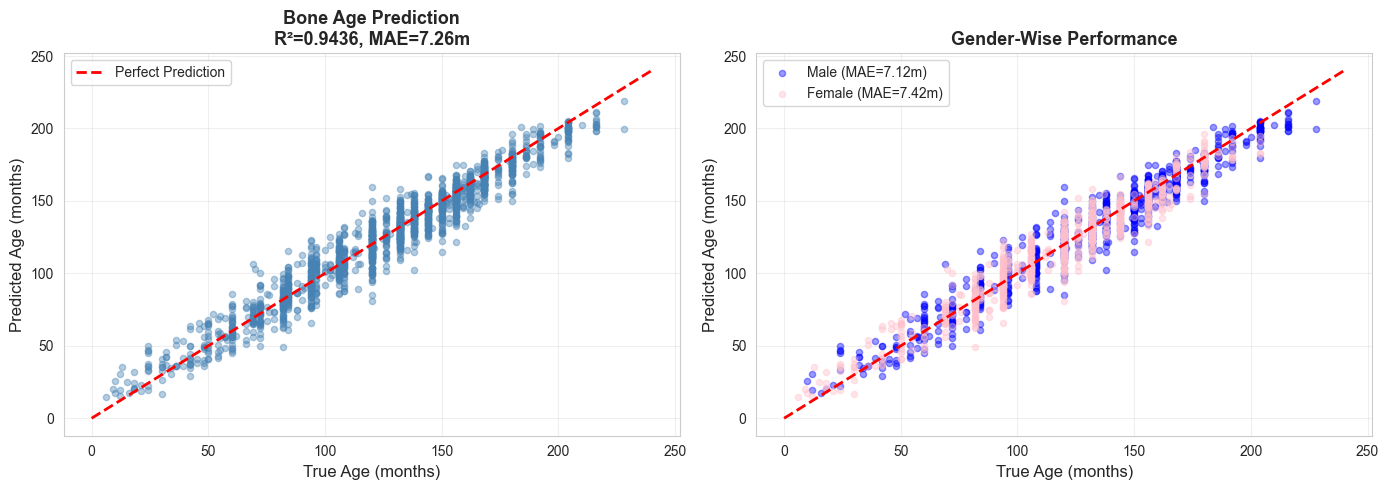

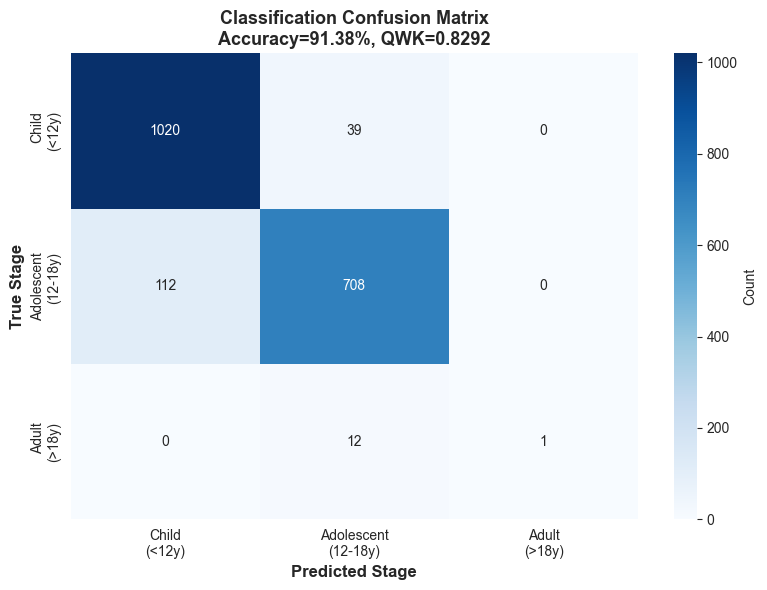

C:\Users\gouth\AppData\Local\Temp\ipykernel_2740\1453567263.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0, 1].boxplot(stage_errors, labels=stage_names, patch_artist=True)
C:\Users\gouth\AppData\Local\Temp\ipykernel_2740\1453567263.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1, 1].boxplot(gender_data, labels=['Male', 'Female'], patch_artist=True)


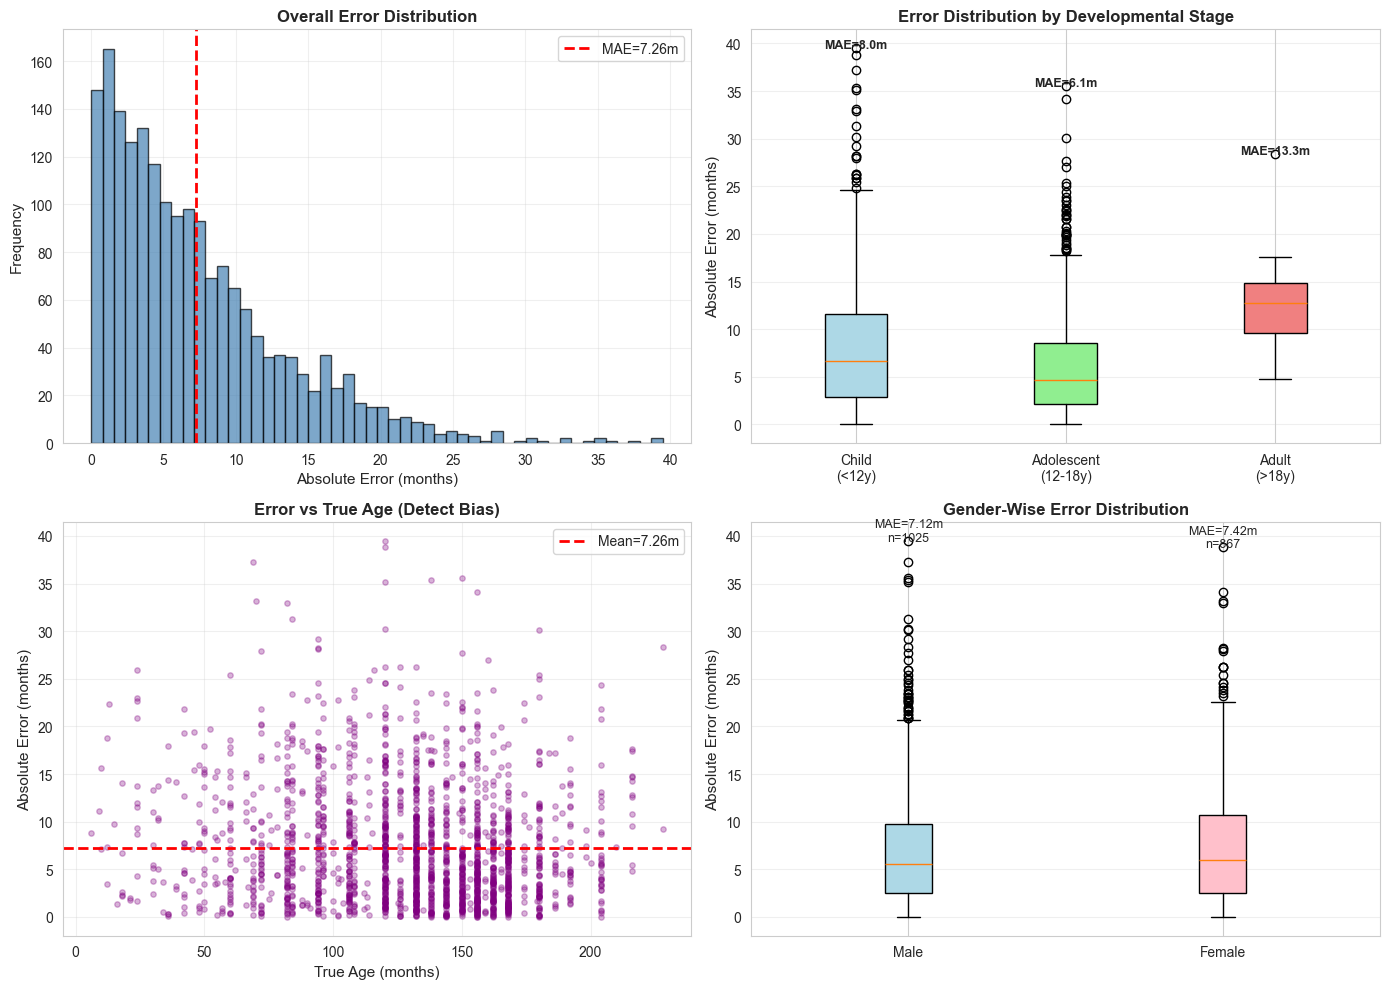

✅ All visualizations saved!


In [15]:
# ==========================================
# 11. COMPLETE VISUALIZATION SUITE
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# ==========================================
# VIZ 1: Scatter Plot (Predicted vs Actual)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall scatter
axes[0].scatter(y_true_age, final_pred_age, alpha=0.4, s=20, c='steelblue')
axes[0].plot([0, 240], [0, 240], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('True Age (months)', fontsize=12)
axes[0].set_ylabel('Predicted Age (months)', fontsize=12)
axes[0].set_title(f'Bone Age Prediction\nR²={r2:.4f}, MAE={mae:.2f}m', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# By gender
male_mask = (sex_list_eval == 1)
female_mask = (sex_list_eval == 0)

axes[1].scatter(y_true_age[male_mask], final_pred_age[male_mask], 
                alpha=0.4, s=20, c='blue', label=f'Male (MAE={np.mean(errors[male_mask]):.2f}m)')
axes[1].scatter(y_true_age[female_mask], final_pred_age[female_mask], 
                alpha=0.4, s=20, c='pink', label=f'Female (MAE={np.mean(errors[female_mask]):.2f}m)')
axes[1].plot([0, 240], [0, 240], 'r--', linewidth=2)
axes[1].set_xlabel('True Age (months)', fontsize=12)
axes[1].set_ylabel('Predicted Age (months)', fontsize=12)
axes[1].set_title('Gender-Wise Performance', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('scatter_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# VIZ 2: Confusion Matrix (Classification)
# ==========================================
cm = confusion_matrix(y_true_stage, final_pred_stage)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Child\n(<12y)', 'Adolescent\n(12-18y)', 'Adult\n(>18y)'],
            yticklabels=['Child\n(<12y)', 'Adolescent\n(12-18y)', 'Adult\n(>18y)'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Stage', fontsize=12, fontweight='bold')
plt.ylabel('True Stage', fontsize=12, fontweight='bold')
plt.title(f'Classification Confusion Matrix\nAccuracy={acc*100:.2f}%, QWK={qwk:.4f}', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# VIZ 3: Error Distribution Analysis
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 3a. Error histogram
axes[0, 0].hist(errors, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 0].axvline(mae, color='red', linestyle='--', linewidth=2, label=f'MAE={mae:.2f}m')
axes[0, 0].set_xlabel('Absolute Error (months)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Overall Error Distribution', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 3b. Error by developmental stage
stage_names = ['Child\n(<12y)', 'Adolescent\n(12-18y)', 'Adult\n(>18y)']
stage_errors = [errors[y_true_stage == i] for i in range(3)]
bp = axes[0, 1].boxplot(stage_errors, labels=stage_names, patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightblue', 'lightgreen', 'lightcoral']):
    patch.set_facecolor(color)
axes[0, 1].set_ylabel('Absolute Error (months)', fontsize=11)
axes[0, 1].set_title('Error Distribution by Developmental Stage', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3, axis='y')

# Add MAE text
for i, stage_err in enumerate(stage_errors):
    axes[0, 1].text(i+1, np.max(stage_err), f'MAE={np.mean(stage_err):.1f}m', 
                    ha='center', fontsize=9, fontweight='bold')

# 3c. Error vs True Age
axes[1, 0].scatter(y_true_age, errors, alpha=0.3, s=15, c='purple')
axes[1, 0].axhline(mae, color='red', linestyle='--', linewidth=2, label=f'Mean={mae:.2f}m')
axes[1, 0].set_xlabel('True Age (months)', fontsize=11)
axes[1, 0].set_ylabel('Absolute Error (months)', fontsize=11)
axes[1, 0].set_title('Error vs True Age (Detect Bias)', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 3d. Gender comparison
gender_data = [errors[male_mask], errors[female_mask]]
bp2 = axes[1, 1].boxplot(gender_data, labels=['Male', 'Female'], patch_artist=True)
bp2['boxes'][0].set_facecolor('lightblue')
bp2['boxes'][1].set_facecolor('pink')
axes[1, 1].set_ylabel('Absolute Error (months)', fontsize=11)
axes[1, 1].set_title('Gender-Wise Error Distribution', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='y')

# Add stats
axes[1, 1].text(1, np.max(errors[male_mask]), 
                f'MAE={np.mean(errors[male_mask]):.2f}m\nn={male_mask.sum()}', 
                ha='center', fontsize=9)
axes[1, 1].text(2, np.max(errors[female_mask]), 
                f'MAE={np.mean(errors[female_mask]):.2f}m\nn={female_mask.sum()}', 
                ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ All visualizations saved!")

📊 ABLATION STUDY: Component Contributions

               Model  MAE (months)  R² Score
Ensemble (Optimized)      7.257663  0.943590
        XGBoost Only      7.276686  0.943212
          Ridge Only      9.174281  0.900720
  Deep Learning Only     10.350330  0.817526

🏆 Best Model: Ensemble (MAE improved by 3.09 months)
   Optimal Weights: DL=0.036, XGB=0.873, Ridge=0.091


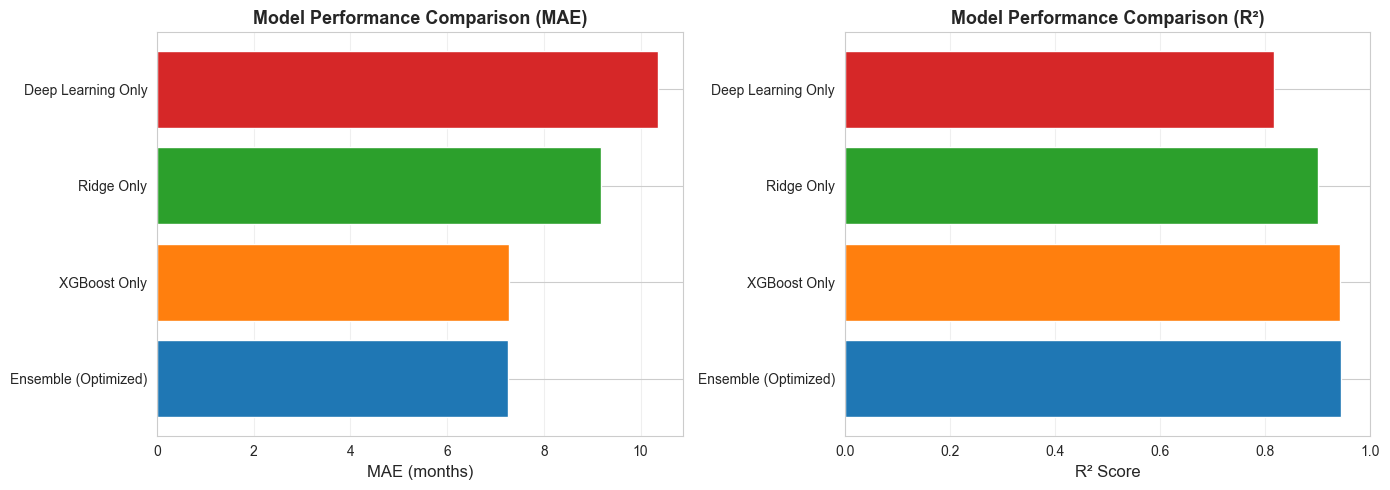

In [16]:
# ==========================================
# 12. MODEL COMPONENT COMPARISON
# ==========================================
print("📊 ABLATION STUDY: Component Contributions\n")

# Individual model performances
models_mae = {
    'Deep Learning Only': mean_absolute_error(y_true_age, dl_test_pred),
    'XGBoost Only': mean_absolute_error(y_true_age, xgb_test_pred),
    'Ridge Only': mean_absolute_error(y_true_age, ridge_test_pred),
    'Ensemble (Optimized)': mae
}

models_r2 = {
    'Deep Learning Only': r2_score(y_true_age, dl_test_pred),
    'XGBoost Only': r2_score(y_true_age, xgb_test_pred),
    'Ridge Only': r2_score(y_true_age, ridge_test_pred),
    'Ensemble (Optimized)': r2
}

# Create comparison table
comparison_df = pd.DataFrame({
    'Model': list(models_mae.keys()),
    'MAE (months)': list(models_mae.values()),
    'R² Score': list(models_r2.values())
})
comparison_df = comparison_df.sort_values('MAE (months)')

print(comparison_df.to_string(index=False))
print(f"\n🏆 Best Model: Ensemble (MAE improved by {models_mae['Deep Learning Only'] - mae:.2f} months)")
print(f"   Optimal Weights: DL={opt_weights[0]:.3f}, XGB={opt_weights[1]:.3f}, Ridge={opt_weights[2]:.3f}")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE comparison
axes[0].barh(comparison_df['Model'], comparison_df['MAE (months)'], 
             color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0].set_xlabel('MAE (months)', fontsize=12)
axes[0].set_title('Model Performance Comparison (MAE)', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3, axis='x')

# R² comparison
axes[1].barh(comparison_df['Model'], comparison_df['R² Score'], 
             color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1].set_xlabel('R² Score', fontsize=12)
axes[1].set_title('Model Performance Comparison (R²)', fontsize=13, fontweight='bold')
axes[1].set_xlim([0, 1])
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# ==========================================
# 13. IDENTIFY & ANALYZE DIFFICULT CASES
# ==========================================
print("🔍 ANALYZING DIFFICULT CASES (Top 20 Worst Predictions)\n")

# Find worst predictions
worst_indices = np.argsort(errors)[-20:][::-1]

difficult_cases = pd.DataFrame({
    'True Age (months)': y_true_age[worst_indices],
    'Predicted Age (months)': final_pred_age[worst_indices],
    'Error (months)': errors[worst_indices],
    'Sex': ['Male' if sex_list_eval[i] == 1 else 'Female' for i in worst_indices],
    'True Stage': [stage_names[y_true_stage[i]] for i in worst_indices],
    'Pred Stage': [stage_names[final_pred_stage[i]] for i in worst_indices]
})

print(difficult_cases.to_string(index=False))

# Analyze patterns
print(f"\n📌 INSIGHTS:")
print(f"   • Average error in difficult cases: {errors[worst_indices].mean():.2f} months")
print(f"   • Stage misclassification rate: {(difficult_cases['True Stage'] != difficult_cases['Pred Stage']).sum()}/20")

# Age range analysis
age_ranges = {
    'Child (0-12y)': (y_true_age < 144).sum(),
    'Adolescent (12-18y)': ((y_true_age >= 144) & (y_true_age < 216)).sum(),
    'Adult (18+y)': (y_true_age >= 216).sum()
}
print(f"\n   • Dataset distribution:")
for stage, count in age_ranges.items():
    print(f"     - {stage}: {count} samples ({count/len(y_true_age)*100:.1f}%)")

# Check if errors concentrate in specific age range
difficult_age_dist = {
    'Child': (y_true_age[worst_indices] < 144).sum(),
    'Adolescent': ((y_true_age[worst_indices] >= 144) & (y_true_age[worst_indices] < 216)).sum(),
    'Adult': (y_true_age[worst_indices] >= 216).sum()
}
print(f"\n   • Difficult cases distribution:")
for stage, count in difficult_age_dist.items():
    print(f"     - {stage}: {count}/20 ({count/20*100:.0f}%)")

🔍 ANALYZING DIFFICULT CASES (Top 20 Worst Predictions)

 True Age (months)  Predicted Age (months)  Error (months)    Sex           True Stage           Pred Stage
             120.0              159.488609       39.488609   Male        Child\n(<12y) Adolescent\n(12-18y)
             120.0               81.204909       38.795091 Female        Child\n(<12y)        Child\n(<12y)
              69.0              106.249969       37.249969   Male        Child\n(<12y)        Child\n(<12y)
             150.0              114.421933       35.578067   Male Adolescent\n(12-18y)        Child\n(<12y)
             138.0              102.634547       35.365453   Male        Child\n(<12y)        Child\n(<12y)
             120.0               84.860961       35.139039   Male        Child\n(<12y)        Child\n(<12y)
             156.0              121.846237       34.153763 Female Adolescent\n(12-18y)        Child\n(<12y)
              70.0              103.123803       33.123803 Female        Child\n

c:\Users\gouth\OneDrive\Desktop\prmlpro\bone_env\lib\site-packages\torch\nn\modules\module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


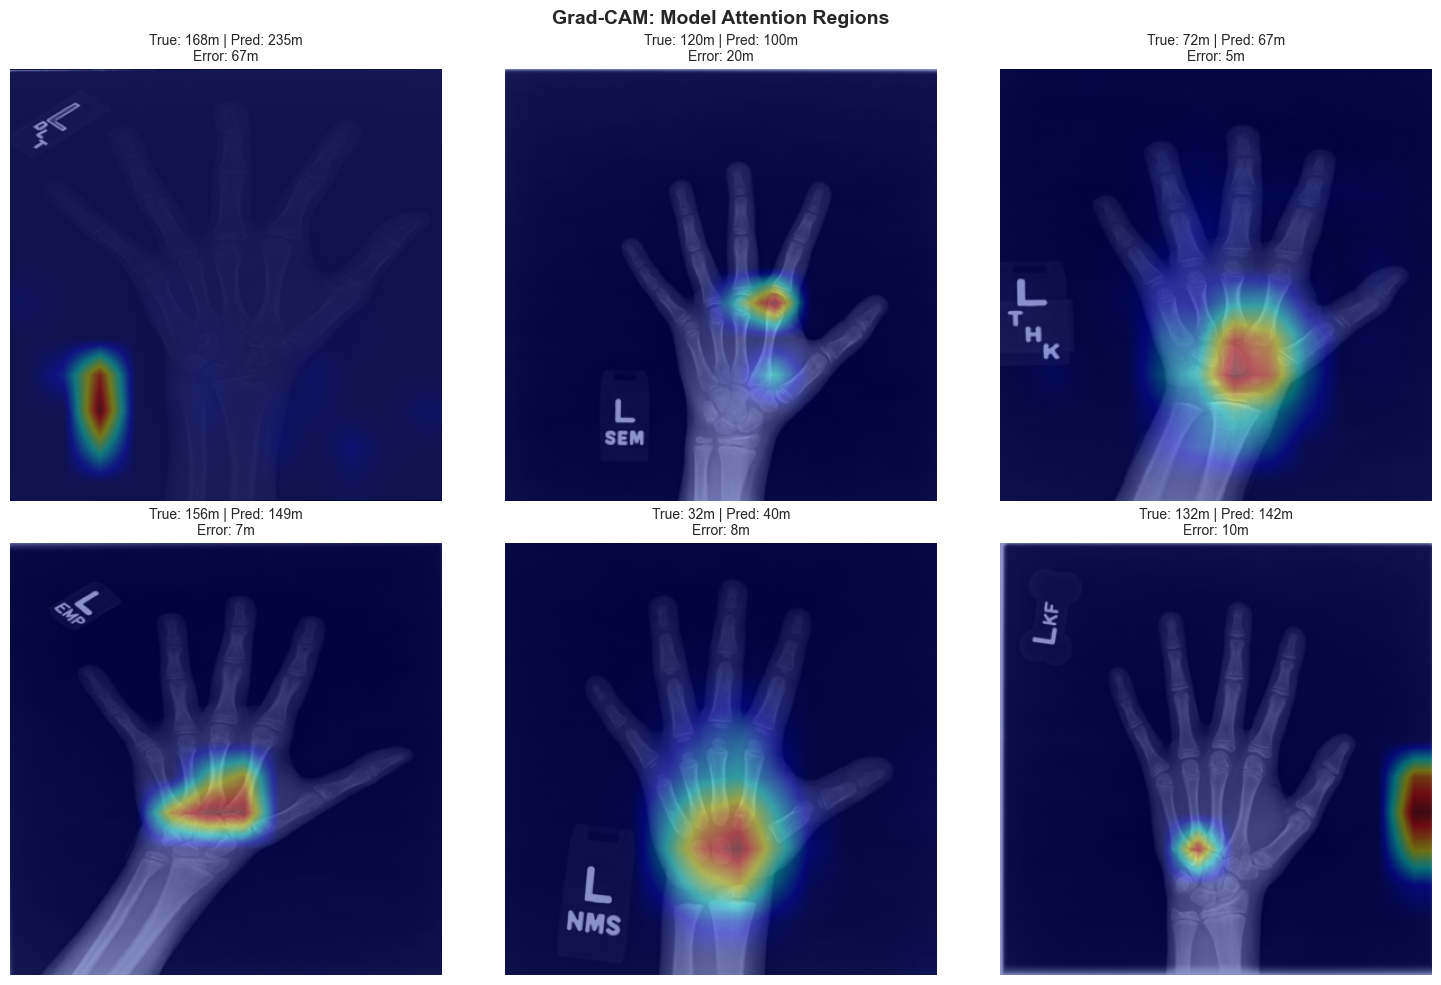

✅ Grad-CAM visualization saved!


In [18]:
# ==========================================
# 14. GRAD-CAM VISUALIZATION
# ==========================================
from torch.nn import functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate(self, img, sex):
        self.model.eval()
        
        # Forward pass
        pred_age, _ = self.model(img, sex)
        
        # Backward pass
        self.model.zero_grad()
        pred_age.backward()
        
        # Generate heatmap
        pooled_gradients = torch.mean(self.gradients, dim=[2, 3], keepdim=True)
        weighted_activations = self.activations * pooled_gradients
        heatmap = torch.mean(weighted_activations, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap /= torch.max(heatmap)
        
        return heatmap.cpu().numpy()

# Get sample images
sample_loader = DataLoader(BoneAgeDataset(internal_test_df.head(6), val_tfm), batch_size=6)
sample_imgs, sample_sexes, sample_ages, _ = next(iter(sample_loader))

# Initialize Grad-CAM (target last conv layer of ResNet)
gradcam = GradCAM(model, model.backbone.layer4[-1].conv3)

# Generate visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i in range(6):
    img = sample_imgs[i:i+1].to(DEVICE).requires_grad_()
    sex = sample_sexes[i:i+1].to(DEVICE)
    
    # Generate heatmap
    heatmap = gradcam.generate(img, sex)
    
    # Get prediction
    with torch.no_grad():
        pred, _ = model(img, sex)
        pred_age = (pred * MAX_AGE_SCALE).item()
    
    true_age = sample_ages[i].item()
    
    # Overlay heatmap
    img_np = img[0].cpu().detach().numpy().transpose(1, 2, 0)
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
    
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0
    
    overlay = 0.6 * img_np + 0.4 * heatmap_colored
    
    axes[i].imshow(overlay)
    axes[i].set_title(f'True: {true_age:.0f}m | Pred: {pred_age:.0f}m\nError: {abs(true_age-pred_age):.0f}m',
                     fontsize=10)
    axes[i].axis('off')

plt.suptitle('Grad-CAM: Model Attention Regions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gradcam_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Grad-CAM visualization saved!")